# Лабораторна робота №1
Кудермін Роман

Варіант 4

![Мем](meme.jpeg)

# Задача №1

Студентка Валентина незалежним чином підкидає три гральні кубики.  
Нас цікавить найбільша кількість очок з трьох підкидань, $\xi$.

$$ M = \{\xi \in \{5, 6\}\}. $$

---

## I. Теоретичні викладки

### 1. Знайдіть розподіл $\xi$. Обчисліть $\mathbb{P}(M)$.

Розглянемо ймовірнісну трійку:
$$
(\Omega, \mathcal{F}, \mathbb{P})
$$

#### Простір елементарних подій
$$
\Omega = \{1,2,3,4,5,6\}^3, \quad |\Omega| = 216.
$$

#### Ймовірність
Усі елементарні події рівноймовірні:
$$
\mathbb{P}(\omega) = \frac{1}{216}, \quad \omega \in \Omega.
$$

---

### Випадкові величини

Нехай $X_1, X_2, X_3$ — результати підкидання кубиків:
$$
X_i \sim \text{Uniform}(\{1,2,3,4,5,6\}), \quad i=1,2,3.
$$

Визначимо:
$$
\xi = \max(X_1, X_2, X_3).
$$

---

### Розподіл $\xi$

Функція розподілу:
$$
F_\xi(k) = \mathbb{P}(\xi \le k)
$$

Подія $\{\xi \le k\}$ еквівалентна події:
$$
\{X_1 \le k, X_2 \le k, X_3 \le k\}
$$

За незалежністю та рівномірністю:
$$
F_\xi(k)
= \left(\mathbb{P}(X_1 \le k)\right)^3
= \left(\frac{k}{6}\right)^3
= \frac{k^3}{216}.
$$

---

Функція ймовірностей:
$$
\mathbb{P}(\xi = k)
= F_\xi(k) - F_\xi(k-1)
= \frac{k^3 - (k-1)^3}{216}, \quad k=1,\dots,6.
$$

---

### Подія $M$

$$
M = \{\xi \ge 5\}
$$

$$
\mathbb{P}(M)
= \mathbb{P}(\xi=5) + \mathbb{P}(\xi=6)
= \frac{61}{216} + \frac{91}{216}
= \frac{152}{216}
= \frac{19}{27} \approx 0.7037.$$

---

### 2. Обчисліть $\mathbb{E}[\xi]$, $\mathrm{Var}(\xi)$

#### Математичне сподівання
$$
\mathbb{E}[\xi]
= \sum_{k=1}^{6} k \mathbb{P}(\xi=k)
= \frac{119}{24} \approx 4.958.$$.


---

#### Другий момент
$$
\mathbb{E}[\xi^2]
= \sum_{k=1}^{6} k^2 \mathbb{P}(\xi=k)
= \frac{5593}{216}  \approx 25.894.$$.


---

#### Дисперсія
$$
\mathrm{Var}(\xi)
= \mathbb{E}[\xi^2] - (\mathbb{E}[\xi])^2
= \frac{2261}{1728}  \approx 1.308.$$.


In [16]:
import numpy as np
import pandas as pd

np.random.seed(42)
# I. Теорія
k = np.arange(1, 7)
p_k = (k**3 - (k - 1)**3) / 216

theory_df = pd.DataFrame({
    "xi": k,
    "P(xi)": p_k,
    "k*P(xi)": k * p_k,
    "k^2*P(xi)": (k**2) * p_k
})

E_xi = (k * p_k).sum()
E_xi2 = ((k**2) * p_k).sum()
Var_xi = E_xi2 - E_xi**2
P_M = p_k[4] + p_k[5]

print("\t\tI. ТЕОРЕТИЧНІ ЗНАЧЕННЯ\n")
print(theory_df.to_string(index=False))

summary_theory = pd.DataFrame([{
    "P(M)": P_M,
    "E[xi]": E_xi,
    "Var[xi]": Var_xi
}])

print("\n\t\tПідсумок:")
print(summary_theory.to_string(index=False))
# II. Повний перебір

d1, d2, d3 = np.meshgrid(np.arange(1,7), np.arange(1,7), np.arange(1,7))
outcomes = np.vstack([d1.ravel(), d2.ravel(), d3.ravel()]).T
xi = np.max(outcomes, axis=1)

brute_df = pd.DataFrame({
    "xi": xi
})

brute_summary = pd.DataFrame([{
    "P(M)": np.mean((xi == 5) | (xi == 6)),
    "E[xi]": np.mean(xi),
    "Var[xi]": np.var(xi)
}])

print("\n\n\t\tII. ПОВНИЙ ПЕРЕБІР")
print(brute_summary.to_string(index=False))

# III. Симуляції
nsim = [100, 1000, 10000]
sim_results = []
for n in nsim:
    throws = np.random.randint(1, 7, size=(n, 3))
    xi_sim = np.max(throws, axis=1)

    sim_results.append({
        "N": n,
        "P(M)": np.mean((xi_sim == 5) | (xi_sim == 6)),
        "E[xi]": np.mean(xi_sim),
        "Var[xi]": np.var(xi_sim)
    })

sim_df = pd.DataFrame(sim_results)
print("\n\n\t\tIII. СИМУЛЯЦІЇ\n")
print(sim_df.to_string(index=False))

comparison = pd.DataFrame([{
    "Theory_P(M)": P_M,
    "Brute_P(M)": brute_summary["P(M)"][0],
    "Sim_P(M)": sim_df["P(M)"].iloc[-1]
}])

print("\n\n\t\tПорівняння\n")
print(comparison)

# Висновок
print("\nВИСНОВКИ")
print("1. Теорія, повний перебір і симуляції дають майже однакові результати.")
print("2. Зі збільшенням N симуляції стабілізуються (згідно закону великих чисел)")


		I. ТЕОРЕТИЧНІ ЗНАЧЕННЯ

 xi    P(xi)  k*P(xi)  k^2*P(xi)
  1 0.004630 0.004630   0.004630
  2 0.032407 0.064815   0.129630
  3 0.087963 0.263889   0.791667
  4 0.171296 0.685185   2.740741
  5 0.282407 1.412037   7.060185
  6 0.421296 2.527778  15.166667

		Підсумок:
    P(M)    E[xi]  Var[xi]
0.703704 4.958333 1.308449


		II. ПОВНИЙ ПЕРЕБІР
    P(M)    E[xi]  Var[xi]
0.703704 4.958333 1.308449


		III. СИМУЛЯЦІЇ

    N   P(M)  E[xi]  Var[xi]
  100 0.6000  4.800 1.500000
 1000 0.7310  5.003 1.252991
10000 0.7046  4.958 1.303436


		Порівняння

   Theory_P(M)  Brute_P(M)  Sim_P(M)
0     0.703704    0.703704    0.7046

ВИСНОВКИ
1. Теорія, повний перебір і симуляції дають майже однакові результати.
2. Зі збільшенням N симуляції стабілізуються (згідно закону великих чисел)


# Задача 2

Нехай задано абсолютно неперервну випадкову величину $\xi$ зі щільністю розподілу:
$$
f(t) = C \exp(-|t + 1|).
$$

---

## I. Теоретичні викладки

### 1. Знаходження сталої $C$

Знайдемо сталу $C$, при якій $f(t)$ є щільністю розподілу.

За означенням щільності:
$$
\int_{-\infty}^{\infty} f(t)\,dt = 1.
$$

Підставимо функцію:
$$
\int_{-\infty}^{\infty} C e^{-|t + 1|} \, dt = 1.
$$

Зробимо заміну $u = t + 1$, $du = dt$:
$$
C \int_{-\infty}^{\infty} e^{-|u|} \, du = 1.
$$

Оскільки функція парна:
$$
C \cdot 2 \int_{0}^{\infty} e^{-u} \, du = 1.
$$

Обчислюємо інтеграл:
$$
\int_{0}^{\infty} e^{-u} \, du = 1.
$$

Отже:
$$
2C = 1 \Rightarrow C = \frac{1}{2}.
$$

---

### Перевірка

$$
\int_{-\infty}^{\infty} \frac{1}{2} e^{-|t + 1|} dt = 1.
$$

Отже, щільність:
$$
f(t) = \frac{1}{2} e^{-|t + 1|}.
$$

---

### 2. Функція розподілу $F(t)$, $\mathbb{E}[\xi]$, $\mathrm{Var}[\xi]$

За означенням:
$$
F(t) = \int_{-\infty}^{t} f(x)\,dx.
$$

---

### Випадок 1: $t < -1$

$$
F(t) = \int_{-\infty}^{t} \frac{1}{2} e^{x+1} dx
= \frac{1}{2} e^{t+1}.
$$

---

### Випадок 2: $t \ge -1$

$$
F(t) =
\int_{-\infty}^{-1} \frac{1}{2} e^{x+1} dx +
\int_{-1}^{t} \frac{1}{2} e^{-(x+1)} dx.
$$

$$
F(t) = \frac{1}{2} + \frac{1}{2}\left(1 - e^{-(t+1)}\right)
= 1 - \frac{1}{2} e^{-(t+1)}.
$$

---

### Функція розподілу

$$
F(t) =
\begin{cases}
\frac{1}{2} e^{t+1}, & t < -1, \\
1 - \frac{1}{2} e^{-(t+1)}, & t \ge -1.
\end{cases}
$$

---

### 3. Математичне сподівання

$$
\mathbb{E}[\xi] =
\int_{-\infty}^{\infty} t \cdot \frac{1}{2} e^{-|t+1|} dt.
$$

Заміна $u = t+1$, $t = u-1$:
$$
\mathbb{E}[\xi] =
\frac{1}{2} \int_{-\infty}^{\infty} (u-1)e^{-|u|} du.
$$

Розбиваємо:
$$
\mathbb{E}[\xi] =
\frac{1}{2} \int_{-\infty}^{\infty} u e^{-|u|} du
-
\frac{1}{2} \int_{-\infty}^{\infty} e^{-|u|} du.
$$

Перший інтеграл = 0 (непарна функція), другий = 2:
$$
\mathbb{E}[\xi] = -1.
$$

---

### 4. Другий момент і дисперсія

$$
\mathbb{E}[\xi^2] =
\int_{-\infty}^{\infty} t^2 \cdot \frac{1}{2} e^{-|t+1|} dt.
$$

Заміна $u = t+1$:
$$
t^2 = (u-1)^2 = u^2 - 2u + 1.
$$

$$
\mathbb{E}[\xi^2] =
\frac{1}{2} \int_{-\infty}^{\infty} (u^2 - 2u + 1)e^{-|u|} du.
$$

Розбиваємо:
- $\int u e^{-|u|} du = 0$
- $\int e^{-|u|} du = 2$
- $\int u^2 e^{-|u|} du = 4$

Отже:
$$
\mathbb{E}[\xi^2] = 3.
$$

---

### Дисперсія

$$
\mathrm{Var}(\xi) =
\mathbb{E}[\xi^2] - (\mathbb{E}[\xi])^2
= 3 - 1 = 2.
$$

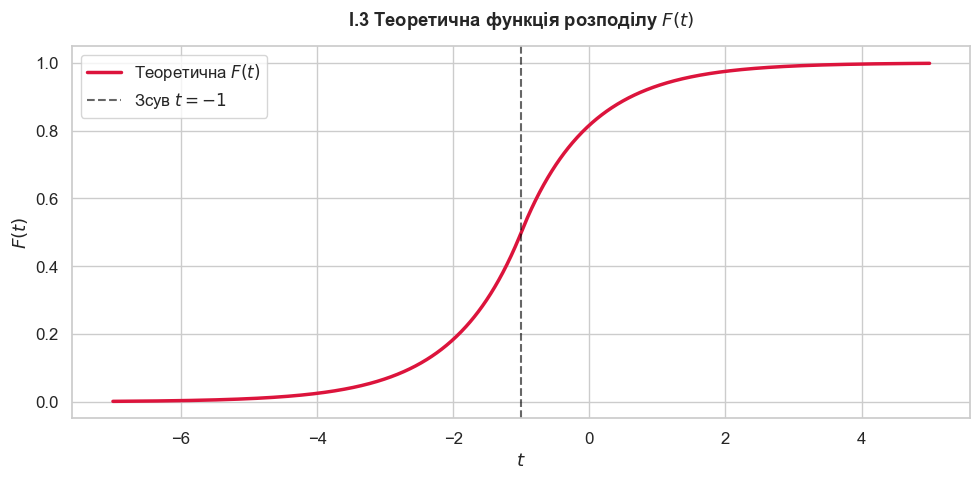

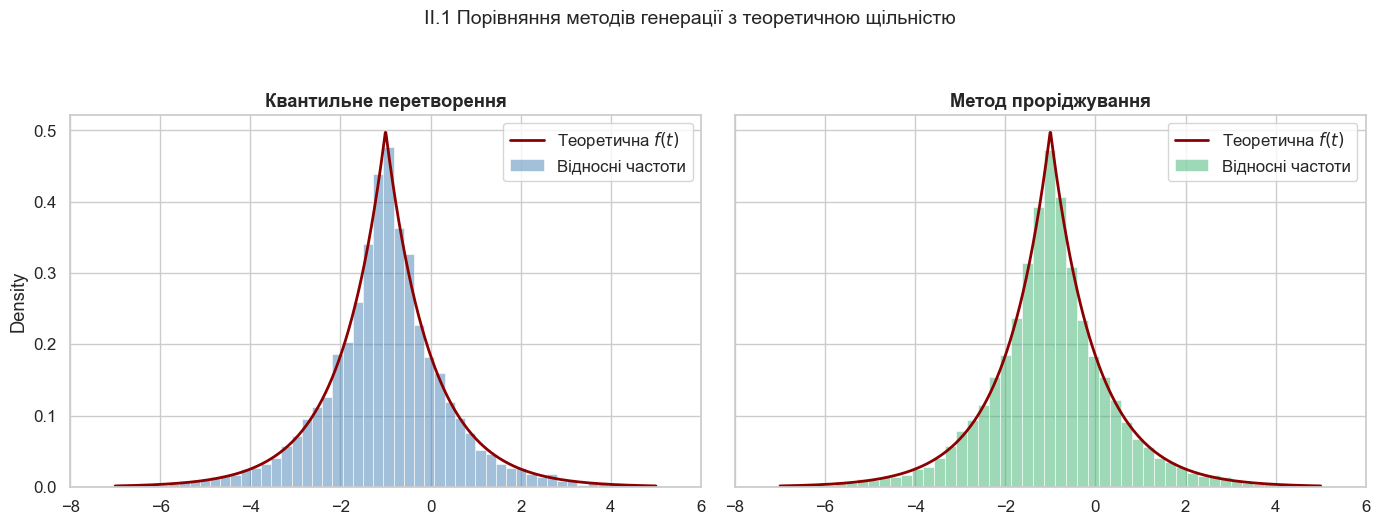

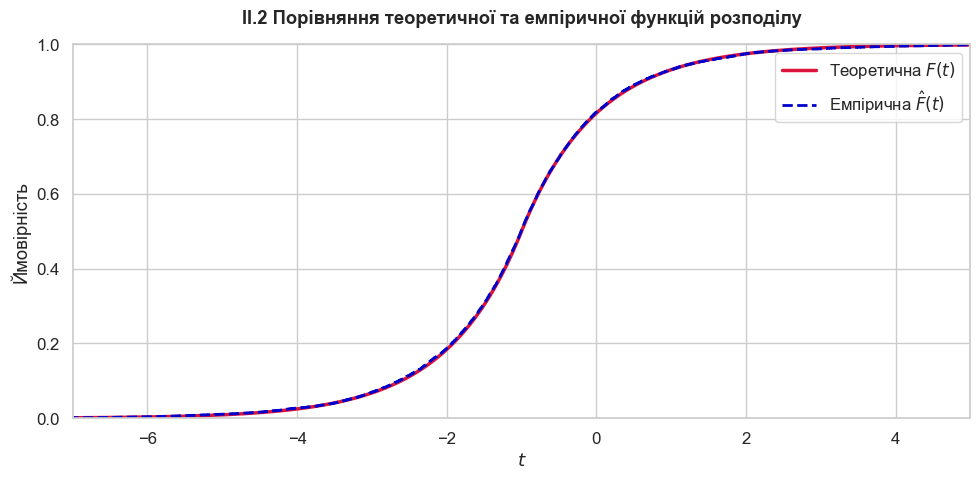

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.integrate as spi

sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)

# I. Теоретичні виклдки.

def f_t(t):
    """Щільність розподілу f(t)"""
    return 0.5 * np.exp(-np.abs(t + 1))

def F_t(t):
    """Теоретична функція розподілу F(t)"""
    return np.where(t < -1, 
                    0.5 * np.exp(t + 1), 
                    1 - 0.5 * np.exp(-(t + 1)))

t_vals = np.linspace(-7, 5, 1000)

#Графік 1: Теоретична функція розподілу
plt.figure(figsize=(10, 5))
sns.lineplot(x=t_vals, y=F_t(t_vals), color="crimson", linewidth=2.5, label="Теоретична $F(t)$")
plt.axvline(-1, color="black", linestyle="--", alpha=0.6, label="Зсув $t = -1$")

plt.title("I.3 Теоретична функція розподілу $F(t)$", pad=15, fontweight='bold')
plt.xlabel("$t$")
plt.ylabel("$F(t)$")
plt.legend()
plt.tight_layout()
plt.show()


# II. Симуляції.

def generate_quantile(B):
    U = np.random.uniform(0, 1, B)
    return np.where(U < 0.5, np.log(2 * U) - 1, -np.log(2 * (1 - U)) - 1)

def generate_rejection(B):
    samples = []
    C = np.pi / 2.0 
    while len(samples) < B:
        V = np.random.standard_cauchy(B) - 1
        U = np.random.uniform(0, 1, B)
        f_V = 0.5 * np.exp(-np.abs(V + 1))
        g_V = 1.0 / (np.pi * (1 + (V + 1)**2))
        accepted = V[U < (f_V / (C * g_V))]
        samples.extend(accepted)
    return np.array(samples[:B])

B_plot = 10000
xi_quant = generate_quantile(B_plot)
xi_rej = generate_rejection(B_plot)

#Графік 2: Гістограми методів
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.histplot(xi_quant, bins=80, stat="density", color="steelblue", alpha=0.5,  #stat="density" автоматично рахує відносні частоти
             edgecolor="white", label="Відносні частоти", ax=axes[0])
sns.lineplot(x=t_vals, y=f_t(t_vals), color="darkred", linewidth=2, label="Теоретична $f(t)$", ax=axes[0])
axes[0].set_title("Квантильне перетворення", fontweight='bold')
axes[0].set_xlim(-8, 6)
axes[0].legend()

sns.histplot(xi_rej, bins=80, stat="density", color="mediumseagreen", alpha=0.5, 
             edgecolor="white", label="Відносні частоти", ax=axes[1])
sns.lineplot(x=t_vals, y=f_t(t_vals), color="darkred", linewidth=2, label="Теоретична $f(t)$", ax=axes[1])
axes[1].set_title("Метод проріджування", fontweight='bold')
axes[1].set_xlim(-8, 6)
axes[1].legend()

plt.suptitle("II.1 Порівняння методів генерації з теоретичною щільністю", y=1.05, fontsize=14)
plt.tight_layout()
plt.show()


# Графік 3: Теоретична vs Емпірична функція розподілу
xi_best = generate_quantile(B_plot)

plt.figure(figsize=(10, 5))

sns.lineplot(x=t_vals, y=F_t(t_vals), color="crimson", linewidth=2.5, label="Теоретична $F(t)$")

sns.ecdfplot(data=xi_best, color="mediumblue", linestyle="--", linewidth=2, label="Емпірична $\hat{F}(t)$")

plt.title("II.2 Порівняння теоретичної та емпіричної функцій розподілу", pad=15, fontweight='bold')
plt.xlabel("$t$")
plt.ylabel("Ймовірність")
plt.xlim(-7, 5)
plt.legend()
plt.tight_layout()
plt.show()

